## <<- Load the data ->>

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)
data_dir = "./data"

# W -> women's basketball, M -> men's basketball
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

In [198]:
# join men's and women's data into one file
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

In [199]:
season = 2003  # change if you want different cutoff year for your models
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]

## <<- Explore the data ->>

In [200]:
regular_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87182,2026,131,3471,60,3218,48,N,0,25,69,3,16,7,8,8,27,13,7,11,1,9,18,48,4,16,8,8,2,31,9,17,3,6,15
87183,2026,132,3158,68,3220,56,N,0,23,61,9,27,13,21,16,26,12,9,5,1,12,23,58,7,21,3,5,9,25,10,13,2,4,17
87184,2026,132,3192,79,3254,57,H,0,31,60,10,19,7,11,9,32,15,10,4,1,18,19,55,7,20,12,14,5,19,2,11,5,4,15
87185,2026,132,3221,77,3250,70,H,0,31,60,5,17,10,12,13,23,16,12,3,4,10,26,55,9,24,9,12,8,17,17,11,6,2,12


In [201]:
tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,2025,147,3163,78,3425,64,N,0,27,60,10,22,14,17,3,25,16,12,10,2,17,19,58,3,13,23,26,9,26,7,15,8,2,18
957,2025,147,3400,58,3395,47,N,0,24,61,2,3,8,11,8,21,14,7,9,6,20,12,45,4,20,19,21,9,21,8,16,1,3,14
958,2025,151,3163,85,3417,51,N,0,33,60,7,16,12,17,4,23,17,7,13,2,16,20,52,4,16,7,8,6,20,11,18,5,2,12
959,2025,151,3376,74,3400,57,N,0,29,57,7,11,9,12,8,22,17,13,7,5,15,22,56,4,10,9,12,8,18,10,14,6,5,17


In [202]:
# let's take one random team and see its journey during the 2024 season
season = 2024
teamid = 3163

r = regular_results.loc[
    (regular_results["Season"] == season)
    & ((regular_results["WTeamID"] == teamid) | (regular_results["LTeamID"] == teamid))
]
t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & ((tourney_results["WTeamID"] == teamid) | (tourney_results["LTeamID"] == teamid))
]
r["win"] = np.where(r["WTeamID"] == teamid, "win", "lose")
t["win"] = np.where(t["WTeamID"] == teamid, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
rt[["DayNum", "WScore", "LScore", "type", "win"]]

,DayNum,WScore,LScore,type,win
70978,2,102,58,regular season,win
71162,6,92,81,regular season,lose
71309,10,80,48,regular season,win
71432,13,62,44,regular season,win
71679,18,78,67,regular season,lose
71703,19,71,63,regular season,win
72099,27,80,68,regular season,lose
72161,30,90,63,regular season,win
72306,34,76,64,regular season,win
72433,40,86,62,regular season,win


In [203]:
seeds

,Season,Seed,TeamID
1154,2003,W01,1328
1155,2003,W02,1448
1156,2003,W03,1393
1157,2003,W04,1257
1158,2003,W05,1280
...,...,...,...
1807,2026,Z12,3211
1808,2026,Z13,3453
1809,2026,Z14,3158
1810,2026,Z15,3239


In [204]:
# structure of seeds by division
s = W_seeds.loc[W_seeds["Season"] == 2015]
[s.loc[s["Seed"].str.startswith(d)] for d in ("X", "Y", "Z", "W")]

[      Season Seed  TeamID
 1104    2015  X01    3268
 1105    2015  X02    3397
 1106    2015  X03    3333
 1107    2015  X04    3181
 1108    2015  X05    3280
 1109    2015  X06    3203
 1110    2015  X07    3151
 1111    2015  X08    3343
 1112    2015  X09    3453
 1113    2015  X10    3338
 1114    2015  X11    3211
 1115    2015  X12    3408
 1116    2015  X13    3107
 1117    2015  X14    3355
 1118    2015  X15    3129
 1119    2015  X16    3308,
       Season Seed  TeamID
 1120    2015  Y01    3376
 1121    2015  Y02    3199
 1122    2015  Y03    3113
 1123    2015  Y04    3314
 1124    2015  Y05    3326
 1125    2015  Y06    3401
 1126    2015  Y07    3195
 1127    2015  Y08    3393
 1128    2015  Y09    3304
 1129    2015  Y10    3329
 1130    2015  Y11    3114
 1131    2015  Y12    3241
 1132    2015  Y13    3251
 1133    2015  Y14    3325
 1134    2015  Y15    3106
 1135    2015  Y16    3366,
       Season Seed  TeamID
 1136    2015  Z01    3323
 1137    2015  Z02    3124

In [205]:
# let's see what seed our previous example team had
seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == teamid)]

,Season,Seed,TeamID
1660,2024,Z03,3163


## <<- Prepare the data ->>

In [206]:
# double the dataset with swapped team positions in box scores
def prepare_data(df):
    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]
    

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

In [207]:
regular_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,6.0,1,1
1,2003,10,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,7.0,1,1
2,2003,11,1437,61.0,1266,73.0,0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,12.0,1,1
3,2003,11,1457,50.0,1296,56.0,0,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,6.0,1,1
4,2003,11,1208,71.0,1400,77.0,0,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,6.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423427,2026,131,3471,60.0,3218,48.0,0,25.0,69.0,3.0,16.0,7.0,8.0,8.0,27.0,13.0,7.0,11.0,1.0,9.0,18.0,48.0,4.0,16.0,8.0,8.0,2.0,31.0,9.0,17.0,3.0,6.0,15.0,-12.0,0,0
423428,2026,132,3158,68.0,3220,56.0,0,23.0,61.0,9.0,27.0,13.0,21.0,16.0,26.0,12.0,9.0,5.0,1.0,12.0,23.0,58.0,7.0,21.0,3.0,5.0,9.0,25.0,10.0,13.0,2.0,4.0,17.0,-12.0,0,0
423429,2026,132,3192,79.0,3254,57.0,0,31.0,60.0,10.0,19.0,7.0,11.0,9.0,32.0,15.0,10.0,4.0,1.0,18.0,19.0,55.0,7.0,20.0,12.0,14.0,5.0,19.0,2.0,11.0,5.0,4.0,15.0,-22.0,0,0
423430,2026,132,3221,77.0,3250,70.0,0,31.0,60.0,5.0,17.0,10.0,12.0,13.0,23.0,16.0,12.0,3.0,4.0,10.0,26.0,55.0,9.0,24.0,9.0,12.0,8.0,17.0,17.0,11.0,6.0,2.0,12.0,-7.0,0,0


In [208]:
tourney_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,134,1411,74.666667,1421,81.777778,1,25.777778,59.555556,10.666667,27.555556,12.444444,27.555556,15.111111,24.888889,14.222222,13.333333,4.444444,0.000000,19.555556,28.444444,61.333333,9.777778,25.777778,15.111111,23.111111,12.444444,26.666667,15.111111,10.666667,4.444444,2.666667,19.555556,7.111111,1,1
1,2003,136,1436,51.000000,1112,80.000000,0,20.000000,64.000000,4.000000,16.000000,7.000000,7.000000,8.000000,26.000000,12.000000,17.000000,10.000000,3.000000,15.000000,31.000000,66.000000,7.000000,23.000000,11.000000,14.000000,11.000000,36.000000,22.000000,16.000000,10.000000,7.000000,8.000000,29.000000,1,1
2,2003,136,1272,71.000000,1113,84.000000,0,25.000000,69.000000,7.000000,28.000000,14.000000,21.000000,20.000000,22.000000,11.000000,12.000000,2.000000,5.000000,18.000000,31.000000,59.000000,6.000000,14.000000,16.000000,22.000000,10.000000,27.000000,18.000000,9.000000,7.000000,4.000000,19.000000,13.000000,1,1
3,2003,136,1166,73.000000,1141,79.000000,0,27.000000,60.000000,7.000000,17.000000,12.000000,17.000000,14.000000,17.000000,20.000000,21.000000,6.000000,6.000000,21.000000,29.000000,53.000000,3.000000,7.000000,18.000000,25.000000,11.000000,20.000000,15.000000,18.000000,13.000000,1.000000,19.000000,6.000000,1,1
4,2003,136,1301,65.777778,1143,67.555556,1,22.222222,49.777778,8.000000,18.666667,13.333333,17.777778,8.888889,23.111111,14.222222,12.444444,4.444444,7.111111,16.888889,24.000000,56.888889,6.222222,17.777778,13.333333,20.444444,16.000000,17.777778,15.111111,11.555556,7.111111,1.777778,12.444444,1.777778,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4815,2025,147,3163,78.000000,3425,64.000000,0,27.000000,60.000000,10.000000,22.000000,14.000000,17.000000,3.000000,25.000000,16.000000,12.000000,10.000000,2.000000,17.000000,19.000000,58.000000,3.000000,13.000000,23.000000,26.000000,9.000000,26.000000,7.000000,15.000000,8.000000,2.000000,18.000000,-14.000000,0,0
4816,2025,147,3400,58.000000,3395,47.000000,0,24.000000,61.000000,2.000000,3.000000,8.000000,11.000000,8.000000,21.000000,14.000000,7.000000,9.000000,6.000000,20.000000,12.000000,45.000000,4.000000,20.000000,19.000000,21.000000,9.000000,21.000000,8.000000,16.000000,1.000000,3.000000,14.000000,-11.000000,0,0
4817,2025,151,3163,85.000000,3417,51.000000,0,33.000000,60.000000,7.000000,16.000000,12.000000,17.000000,4.000000,23.000000,17.000000,7.000000,13.000000,2.000000,16.000000,20.000000,52.000000,4.000000,16.000000,7.000000,8.000000,6.000000,20.000000,11.000000,18.000000,5.000000,2.000000,12.000000,-34.000000,0,0
4818,2025,151,3376,74.000000,3400,57.000000,0,29.000000,57.000000,7.000000,11.000000,9.000000,12.000000,8.000000,22.000000,17.000000,13.000000,7.000000,5.000000,15.000000,22.000000,56.000000,4.000000,10.000000,9.000000,12.000000,8.000000,18.000000,10.000000,14.000000,6.000000,5.000000,17.000000,-17.000000,0,0


In [209]:
# let's take an example match to double check if the same match is entered correctly in our dataset
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
118444,2025,120,1182,62.0,1433,71.0,0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,9.0,1,1
330160,2025,120,1433,71.0,1182,62.0,0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,-9.0,0,1


## <<- Easy difficulty features ->>

In [210]:
# extract seed number from `Seed` field
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
1807,2026,Z12,3211,12
1808,2026,Z13,3453,13
1809,2026,Z14,3158,14
1810,2026,Z15,3239,15


In [211]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


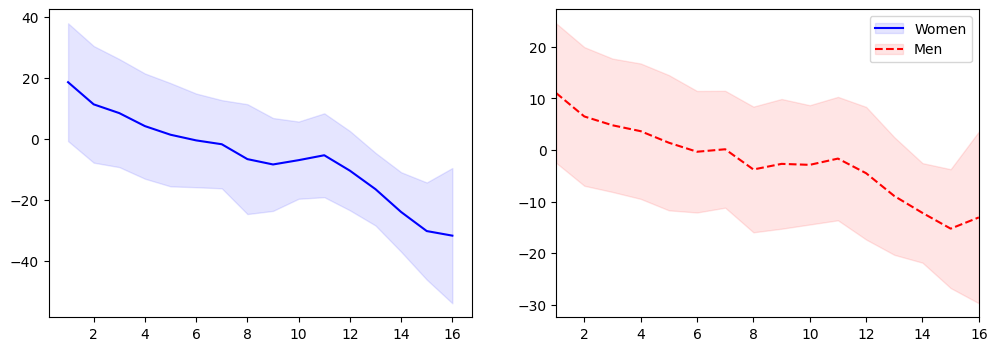

In [212]:
# let's see if __seed__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

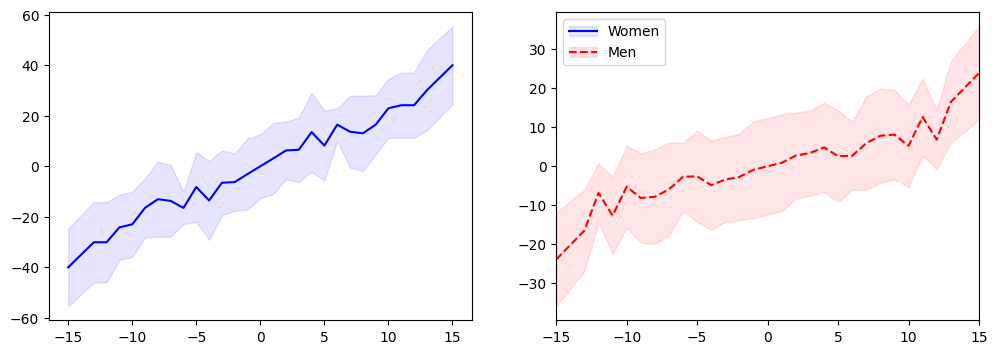

In [213]:
# let's see __seed difference__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

## <<- Medium difficulty features ->>

In [214]:
# box score columns, for which we want features to our model
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

#### 1. Let's define a single match {**`T`**, **`OPP`**}. This means that **`T=TEAM(x)`** plays against an opponent team **`OPP=TEAM(y1)`**
#### 2. During regular season, team **`T`** plays multiple games {**`T`**, **`OPP1`**}, {**`T`**, **`OPP2`**}, ...; against different opponents **`OPP1=TEAM(y1)`**, **`OPP2=TEAM(y2)`**, ...
#### 3. We can calculate regular season average performance for the team **`T`** : **`average[T]`**
#### 4. We can also calculate how opponents perform on average when they play a game against team **`T`** : **`average[T_OPP1,T_OPP2,...]`**
#### 5. Let's play a new match: {**`T1`**, **`T2`**}
#### 6. We can collect performance data for the **`T1`**: **`average[T1]`** and **`average[T1_OPP1,T1_OPP2,...]`**
#### 7. We can collect performance data for the **`T2`**: **`average[T2]`** and **`average[T2_OPP1,T2_OPP2,...]`**
#### 8. Then we can combine all data: **`average[T1]`**,**`average[T1_OPP1,T1_OPP2,...]`**, **`average[T2]`**, **`average[T2_OPP1,T2_OPP2,...]`**
#### 9. Use this data to predict the output of a match between **`T1`** and **`T2`**

In [215]:
# calculate season averages
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,16.903704,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370

## <<- Hard difficulty features ->>

In [216]:
def update_elo(winner_elo, loser_elo):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

base_elo = 1000
elo_width = 400
k_factor = 100

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
elos = pd.concat(elos)

elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

<Axes: xlabel='elo'>

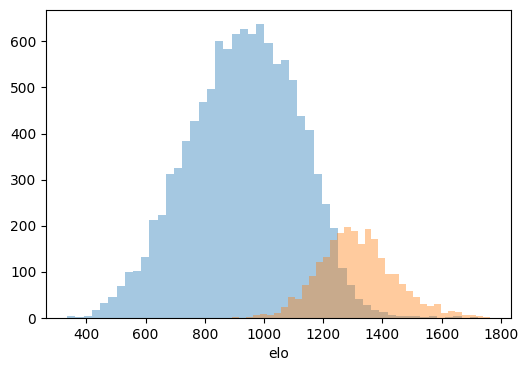

In [217]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')

plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

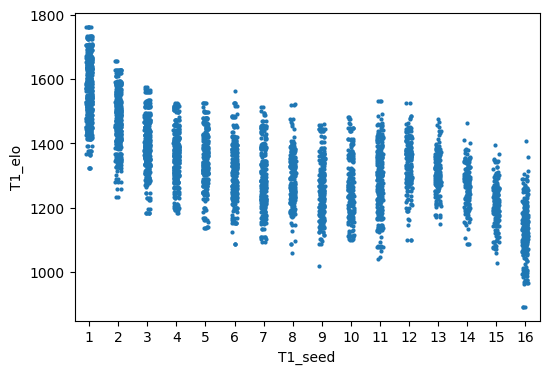

In [218]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

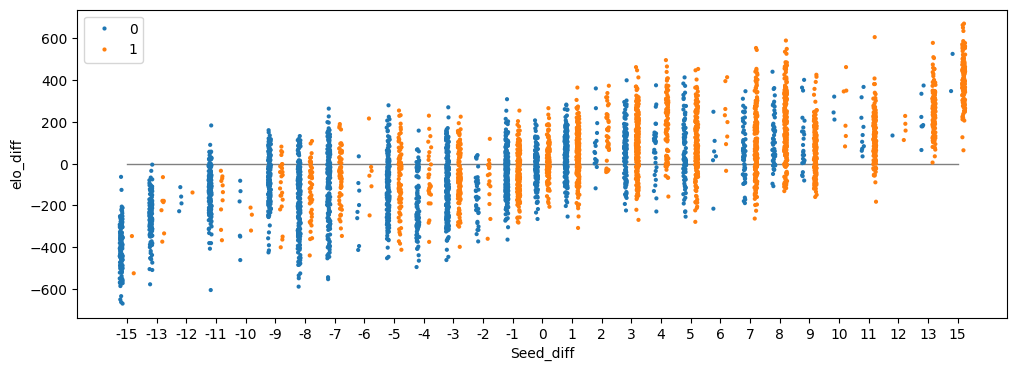

In [219]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
seaborn.lineplot([0]*29,color='gray',lw = 1)

## <<- Hardest difficulty features ->>

In [220]:
import statsmodels.api as sm
import tqdm

regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

100%|██████████| 23/23 [01:30<00:00,  3.93s/season]


<Axes: ylabel='T1_quality'>

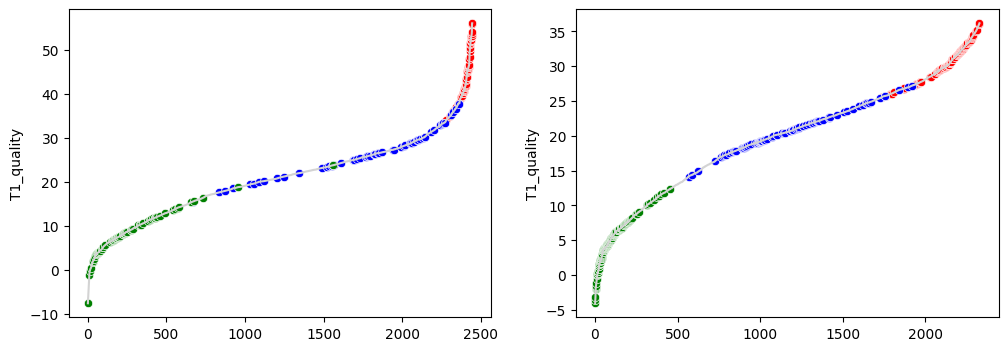

In [221]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])

In [ ]:
## <<- Load Kenpom features ->>

# Load kenpom_pretourney.csv and merge with tournament data by team ID and season
kenpom_path = f"{data_dir}/kenpom_pretourney.csv"
import os
try:
    kenpom = pd.read_csv(kenpom_path)

    # Ensure Season and TeamID columns exist and are in proper format
    if "Season" not in kenpom.columns or "TeamID" not in kenpom.columns:
        raise ValueError("Kenpom CSV must contain 'Season' and 'TeamID' columns")

    kenpom["Season"] = kenpom["Season"].astype(int)
    kenpom["TeamID"] = kenpom["TeamID"].astype(int)

    # Select numerical features (exclude Team identifiers and key columns)
    feature_cols = [
        c for c in kenpom.columns
        if c not in ["Season", "TeamID"] and kenpom[c].dtype in ["int64", "float64"]
    ]
    kenpom = kenpom[["Season", "TeamID"] + feature_cols].copy()

    # Create T1_ and T2_ versions and merge
    rename_dict_T1 = {c: f"T1_{c}" for c in feature_cols}
    rename_dict_T1["TeamID"] = "T1_TeamID"
    kenpom_T1 = kenpom.rename(columns=rename_dict_T1)

    rename_dict_T2 = {c: f"T2_{c}" for c in feature_cols}
    rename_dict_T2["TeamID"] = "T2_TeamID"
    kenpom_T2 = kenpom.rename(columns=rename_dict_T2)

    tourney_data = pd.merge(tourney_data, kenpom_T1, on=["Season", "T1_TeamID"], how="left")
    tourney_data = pd.merge(tourney_data, kenpom_T2, on=["Season", "T2_TeamID"], how="left")
    print(f"Kenpom features merged successfully ({len(feature_cols)} features)")
except FileNotFoundError:
    print(f"Kenpom file not found at {kenpom_path}, skipping kenpom features")
except (ValueError, KeyError) as e:
    print(f"Error processing kenpom file: {e}. Skipping kenpom features.")

In [223]:
# Validate a random subset of merged KenPom features
rng = np.random.default_rng(2026)

if "feature_cols" not in locals() or len(feature_cols) == 0:
    print("KenPom feature list not found. Run the KenPom merge cell first.")
else:
    sample_size = min(6, len(feature_cols))
    sampled_base_cols = rng.choice(feature_cols, size=sample_size, replace=False).tolist()
    sampled_merged_cols = [col for base in sampled_base_cols for col in (f"T1_{base}", f"T2_{base}")]

    coverage = tourney_data[sampled_merged_cols].notna().mean().sort_values()
    print("Sampled KenPom base columns:", sampled_base_cols)
    print("\nNon-null coverage for sampled merged columns:")
    print((coverage * 100).round(2).astype(str) + "%")

    example_cols = ["Season", "T1_TeamID", "T2_TeamID"] + sampled_merged_cols
    print("\nExample populated rows (first 5 where all sampled columns are present):")
    display(tourney_data.loc[tourney_data[sampled_merged_cols].notna().all(axis=1), example_cols].head(5))

    if coverage.min() < 0.9:
        print("\nWarning: Some sampled KenPom columns have <90% non-null coverage.")

Sampled KenPom base columns: ['AdjT_Rk', 'Luck_Rk', 'DRtg', 'Rk', 'L', 'SOS_NetRtg']

Non-null coverage for sampled merged columns:
T1_AdjT_Rk       60.12%
T2_AdjT_Rk       60.12%
T1_Luck_Rk       60.12%
T2_Luck_Rk       60.12%
T1_DRtg          60.12%
T2_DRtg          60.12%
T1_Rk            60.12%
T2_Rk            60.12%
T1_L             60.12%
T2_L             60.12%
T1_SOS_NetRtg    60.12%
T2_SOS_NetRtg    60.12%
dtype: str

Example populated rows (first 5 where all sampled columns are present):


,Season,T1_TeamID,T2_TeamID,T1_AdjT_Rk,T2_AdjT_Rk,T1_Luck_Rk,T2_Luck_Rk,T1_DRtg,T2_DRtg,T1_Rk,T2_Rk,T1_L,T2_L,T1_SOS_NetRtg,T2_SOS_NetRtg
0,2003,1421,1411,118.0,104.0,5.0,75.0,113.5,108.7,283.0,260.0,17.0,13.0,-6.45,-12.96
1,2003,1112,1436,11.0,271.0,181.0,119.0,88.8,99.5,4.0,150.0,4.0,11.0,8.69,-5.14
2,2003,1113,1272,169.0,109.0,201.0,151.0,97.4,94.1,30.0,29.0,12.0,7.0,8.74,4.83
3,2003,1141,1166,20.0,103.0,3.0,99.0,99.4,94.9,70.0,26.0,7.0,5.0,2.06,-0.19
4,2003,1143,1301,208.0,257.0,42.0,223.0,96.3,98.1,47.0,50.0,9.0,13.0,7.06,8.48


In [224]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(data=tmp, index="T1_seed", columns="QualitySeed", values="men_women", aggfunc="count").fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


In [225]:
from sklearn.metrics import roc_auc_score

print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


In [226]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


In [227]:
# Print features as a copyable list
available_features = sorted([col for col in tourney_data.columns if col not in ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]])
print(f"Total available features: {len(available_features)}\n")
print(available_features)

Total available features: 108

['Seed_diff', 'T1_AdjT', 'T1_AdjT_Rk', 'T1_DRtg', 'T1_DRtg_Rk', 'T1_L', 'T1_Luck', 'T1_Luck_Rk', 'T1_NCSOS_NetRtg', 'T1_NCSOS_NetRtg_Rk', 'T1_NetRtg', 'T1_ORtg', 'T1_ORtg_Rk', 'T1_Rk', 'T1_SOS_DRtg', 'T1_SOS_DRtg_Rk', 'T1_SOS_NetRtg', 'T1_SOS_NetRtg_Rk', 'T1_SOS_ORtg', 'T1_SOS_ORtg_Rk', 'T1_W', 'T1_avg_Ast', 'T1_avg_Blk', 'T1_avg_DR', 'T1_avg_FGA', 'T1_avg_FGA3', 'T1_avg_FGM', 'T1_avg_FGM3', 'T1_avg_FTA', 'T1_avg_FTM', 'T1_avg_OR', 'T1_avg_PF', 'T1_avg_PointDiff', 'T1_avg_Score', 'T1_avg_Stl', 'T1_avg_TO', 'T1_avg_opponent_Ast', 'T1_avg_opponent_Blk', 'T1_avg_opponent_DR', 'T1_avg_opponent_FGA', 'T1_avg_opponent_FGA3', 'T1_avg_opponent_FGM', 'T1_avg_opponent_FGM3', 'T1_avg_opponent_FTA', 'T1_avg_opponent_FTM', 'T1_avg_opponent_OR', 'T1_avg_opponent_PF', 'T1_avg_opponent_Score', 'T1_avg_opponent_Stl', 'T1_avg_opponent_TO', 'T1_elo', 'T1_quality', 'T1_seed', 'T2_AdjT', 'T2_AdjT_Rk', 'T2_DRtg', 'T2_DRtg_Rk', 'T2_L', 'T2_Luck', 'T2_Luck_Rk', 'T2_NCSOS_NetRtg'

## <<- Machine Learning model ->>

In [228]:
### EASY FEATURES ###
# "men_women",    
# "T1_seed",
# "T2_seed",
# "Seed_diff",
### MEDIUM FEATURES ###
# "T1_avg_Score",
#"T1_avg_FGM",
# "T1_avg_FGA",
#"T1_avg_FGM3",
#"T1_avg_FGA3",
#"T1_avg_FTM",
#"T1_avg_FTA",
# "T1_avg_OR",
# "T1_avg_DR",
#"T1_avg_Ast",
#"T1_avg_TO",
#"T1_avg_Stl",
# "T1_avg_Blk",
# "T1_avg_PF",
#"T1_avg_opponent_Score",
#"T1_avg_opponent_FGM",
# "T1_avg_opponent_FGA",
#"T1_avg_opponent_FGM3",
#"T1_avg_opponent_FGA3",
#"T1_avg_opponent_FTM",
#"T1_avg_opponent_FTA",
#"T1_avg_opponent_OR",
#"T1_avg_opponent_DR",
#"T1_avg_opponent_Ast",
#"T1_avg_opponent_TO",
#"T1_avg_opponent_Stl",
# "T1_avg_opponent_Blk",
# "T1_avg_opponent_PF",
# "T1_avg_PointDiff",
# "T2_avg_Score",
#"T2_avg_FGM",
# "T2_avg_FGA",
#"T2_avg_FGM3",
#"T2_avg_FGA3",
#"T2_avg_FTM",
#"T2_avg_FTA",
# "T2_avg_OR",
# "T2_avg_DR",
#"T2_avg_Ast",
#"T2_avg_TO",
#"T2_avg_Stl",
# "T2_avg_Blk",
# "T2_avg_PF",
#"T2_avg_opponent_Score",
#"T2_avg_opponent_FGM",
# "T2_avg_opponent_FGA",
#"T2_avg_opponent_FGM3",
#"T2_avg_opponent_FGA3",
#"T2_avg_opponent_FTM",
#"T2_avg_opponent_FTA",
#"T2_avg_opponent_OR",
#"T2_avg_opponent_DR",
#"T2_avg_opponent_Ast",
#"T2_avg_opponent_TO",
#"T2_avg_opponent_Stl",
# "T2_avg_opponent_Blk",
# "T2_avg_opponent_PF",
# "T2_avg_PointDiff",
### HARD FEATURES ###
# "T1_elo",
# "T2_elo",    
# "elo_diff",
### HARDEST FEATURES ###
# "T1_quality",
# "T2_quality",
features = ['Seed_diff', 
            'T1_SOS_NetRtg', 
            'T1_avg_Ast', 
            'T1_avg_Blk', 
            'T1_avg_DR', 
            'T1_avg_FGA', 
            'T1_avg_FGM', 
            'T1_avg_OR', 
            'T1_avg_PF', 
            'T1_avg_PointDiff', 
            'T1_avg_Score', 
            'T1_avg_opponent_Blk', 
            'T1_avg_opponent_FGA', 
            'T1_elo', 
            'T1_quality', 
            'T1_seed', 
            'T2_SOS_NetRtg', 
            'T2_avg_Ast', 
            'T2_avg_Blk', 
            'T2_avg_DR', 
            'T2_avg_FGA', 
            'T2_avg_FGM', 
            'T2_avg_OR', 
            'T2_avg_PF', 
            'T2_avg_PointDiff', 
            'T2_avg_Score', 
            'T2_avg_opponent_Blk', 
            'T2_avg_opponent_FGA', 
            'T2_elo', 
            'T2_quality', 
            'T2_seed', 
            'elo_diff', 
            'men_women'
            ]


print(f"Number of features {len(features)}")

Number of features 39


In [ ]:
import xgboost as xgb

# Set to False to force CPU even when GPU is available.
USE_GPU = False

# The following are the best achieved results from hyperparameter search using tune_xgb_features (and the above feature list)
# Brier Score: 0.142868
# MAE: 8.599078
param = {}
param["objective"] = "reg:squarederror"
param["booster"] = "gbtree"
param["eta"] = 0.005176568349921183 #0.0093  #0.009 #0.01
param["subsample"] = 0.6442801793041767 #0.6
param["colsample_bynode"] = 0.9730692954330715 #0.8
param["num_parallel_tree"] = 3
param["min_child_weight"] = 6 #4
param["max_depth"] = 7 #4
param["tree_method"] = "hist"
param["grow_policy"] = "lossguide"
param["max_bin"] = 62 #38   #32

# these default to 0 and 1 respectively, but are included in the xgb parameter search
param["reg_alpha"] = 0.3273014009831524
param["reg_lambda"] = 0.6911714553354208
param["device"] = "cuda" if USE_GPU else "cpu"

print(f"XGBoost requested device: {'GPU (cuda)' if USE_GPU else 'CPU'}")

num_rounds = 672 #704 #704 #700

XGBoost requested device: CPU


In [230]:
from sklearn.metrics import mean_absolute_error, brier_score_loss

models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season out models
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train)
    print(f"dtrain rows: {dtrain.num_row()}")
    dval = xgb.DMatrix(x_val, label=y_val)

    try:
        models[oof_season] = xgb.train(
            params=param,
            dtrain=dtrain,
            num_boost_round=num_rounds,
        )
    except xgb.core.XGBoostError as ex:
        # If CUDA is unavailable at runtime, retry safely on CPU and continue.
        if param.get("device") == "cuda":
            print(f"CUDA unavailable for season {oof_season}; retrying on CPU. Details: {ex}")
            param["device"] = "cpu"
            models[oof_season] = xgb.train(
                params=param,
                dtrain=dtrain,
                num_boost_round=num_rounds,
            )
        else:
            raise

    preds = models[oof_season].predict(dval)
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds)}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)

print(f"average mae: {np.mean(oof_mae)}")

dtrain rows: 4692
oof season 2003 mae: 7.697821333071786
dtrain rows: 4692
oof season 2004 mae: 6.8855016914241585
dtrain rows: 4692
oof season 2005 mae: 6.7957152275640205
dtrain rows: 4692
oof season 2006 mae: 7.081823325260645
dtrain rows: 4692
oof season 2007 mae: 7.540294371692774
dtrain rows: 4692
oof season 2008 mae: 8.757546785549494
dtrain rows: 4692
oof season 2009 mae: 8.062644050022612
dtrain rows: 4566
oof season 2010 mae: 8.401641378740104
dtrain rows: 4560
oof season 2011 mae: 9.116484001538693
dtrain rows: 4560
oof season 2012 mae: 7.895364300936905
dtrain rows: 4560
oof season 2013 mae: 9.22545194114439
dtrain rows: 4560
oof season 2014 mae: 9.23186457973674
dtrain rows: 4560
oof season 2015 mae: 7.479899347973112
dtrain rows: 4560
oof season 2016 mae: 9.860803670664119
dtrain rows: 4560
oof season 2017 mae: 9.219966647086634
dtrain rows: 4560
oof season 2018 mae: 9.828439473478584
dtrain rows: 4560
oof season 2019 mae: 8.550270084069611
dtrain rows: 4562
oof season 20

<Axes: xlabel='pred_pointdiff', ylabel='average_win_pct'>

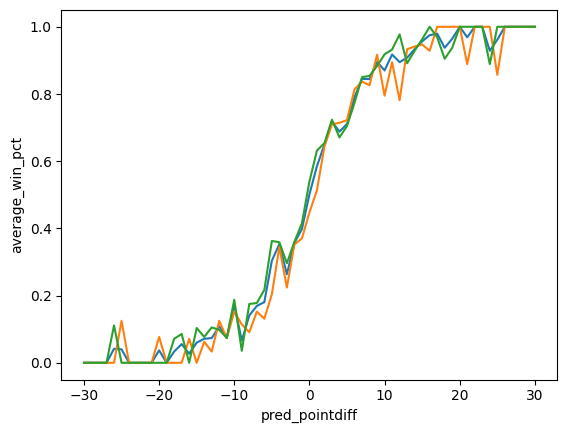

In [231]:
df = pd.DataFrame(
    {"Season": oof_ss, "pred": oof_preds, "label": [(t > 0) * 1 for t in oof_targets], "men_women": tourney_data["men_women"]}
)
df["pred_pointdiff"] = df["pred"].astype(int)

xdf_all = df.clip(-30, 30).groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_men = df.clip(-30, 30).loc[df["men_women"] == 0].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_women = df.clip(-30, 30).loc[df["men_women"] == 1].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")

seaborn.lineplot(x=xdf_all["pred_pointdiff"], y=xdf_all["average_win_pct"])
seaborn.lineplot(x=xdf_men["pred_pointdiff"], y=xdf_men["average_win_pct"])
seaborn.lineplot(x=xdf_women["pred_pointdiff"], y=xdf_women["average_win_pct"])

brier: 0.14282437871486323


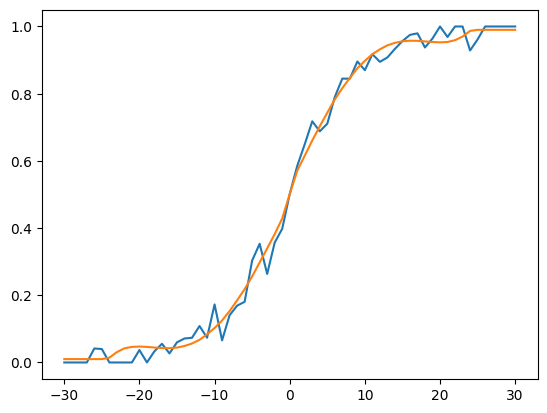

In [232]:
from scipy.interpolate import UnivariateSpline

t = 25
dat = list(zip(oof_preds, np.array(oof_targets)>0))
dat = sorted(dat, key = lambda x: x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=5)
spline_fit = np.clip(spline_model(np.clip(oof_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_pointdiff')[['spline','label']].mean().reset_index()

plt.figure()
plt.plot(xdf['pred_pointdiff'],xdf['label'])
plt.plot(xdf['pred_pointdiff'],xdf['spline'])

In [233]:
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")

for oof_season in set(tourney_data.Season):
    x = df.loc[df["Season"] == oof_season, "spline"].values
    y = df.loc[df["Season"] == oof_season, "label"].values
    print(oof_season, np.round(brier_score_loss(y, x),5))

brier: 0.14282437871486323
2003 0.1298
2004 0.13742
2005 0.11747
2006 0.14454
2007 0.11936
2008 0.12946
2009 0.12387
2010 0.14295
2011 0.1694
2012 0.12804
2013 0.14421
2014 0.14583
2015 0.12492
2016 0.16222
2017 0.13819
2018 0.16273
2019 0.12081
2021 0.15756
2022 0.17968
2023 0.17006
2024 0.1344
2025 0.10898


## <<- Make submission ->>

In [234]:
X = pd.read_csv(f"{data_dir}/SampleSubmissionStage2.csv")
X

,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5
...,...,...
132128,2026_3478_3480,0.5
132129,2026_3478_3481,0.5
132130,2026_3479_3480,0.5
132131,2026_3479_3481,0.5


In [ ]:
# construct dataframe for submission (start fresh each run)
X = pd.read_csv(f"{data_dir}/SampleSubmissionStage2.csv")
X['Season'] = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))
# Keep encoding consistent with training data (men=1 for team IDs that start with '1').
X['men_women'] = X['T1_TeamID'].apply(lambda t: 1 if str(t)[0] == '1' else 0)

X = pd.merge(X, ss_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, ss_T2, on=['Season', 'T2_TeamID'], how='left')
X = pd.merge(X, seeds_T1, on=['Season', 'T1_TeamID'], how='left')
X = pd.merge(X, seeds_T2, on=['Season', 'T2_TeamID'], how='left')
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")

# Build KenPom features for submission directly from source data.
kenpom_sub_path = f"{data_dir}/kenpom_pretourney.csv"
kenpom_sub = pd.read_csv(kenpom_sub_path)
kenpom_sub["Season"] = kenpom_sub["Season"].astype(int)
kenpom_sub["TeamID"] = kenpom_sub["TeamID"].astype(int)

for c in kenpom_sub.columns:
    if c not in ["Season", "TeamID"]:
        kenpom_sub[c] = pd.to_numeric(kenpom_sub[c], errors="coerce")

kenpom_sub_feature_cols = [
    c for c in kenpom_sub.columns
    if c not in ["Season", "TeamID"] and pd.api.types.is_numeric_dtype(kenpom_sub[c])
]
kenpom_sub = kenpom_sub[["Season", "TeamID"] + kenpom_sub_feature_cols].copy()

kenpom_sub_t1 = kenpom_sub.rename(columns={c: f"T1_{c}" for c in kenpom_sub_feature_cols})
kenpom_sub_t1 = kenpom_sub_t1.rename(columns={"TeamID": "T1_TeamID"})
kenpom_sub_t2 = kenpom_sub.rename(columns={c: f"T2_{c}" for c in kenpom_sub_feature_cols})
kenpom_sub_t2 = kenpom_sub_t2.rename(columns={"TeamID": "T2_TeamID"})

X = pd.merge(X, kenpom_sub_t1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, kenpom_sub_t2, on=["Season", "T2_TeamID"], how="left")

X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

In [236]:
# run models on given dataset
missing_features = [f for f in features if f not in X.columns]
if missing_features:
    raise KeyError(f"Submission frame is missing features: {missing_features}")

preds = []
dtest = xgb.DMatrix(X[features].values)
for oof_season in set(tourney_data.Season):
    margin_preds = models[oof_season].predict(dtest) * 1.0 # aggressive submissions >1, conservative submissions <1
    probs = np.clip(spline_model(np.clip(margin_preds, -t, t)), 0.01, 0.99)
    preds.append(probs)
X['Pred'] = np.array(preds).mean(axis=0)

In [237]:
#Manual Overrides; Increase model prediction confidence 

# Step 1: Increase pred by 10% if pred < 85%
X['Pred'] = X['Pred'].apply(lambda x: x + x * 0.1 if x < 0.85 else x)

# Step 2: Apply manual overrides for specific matches
# Matches with low pred compared to expectations for Early rounds
# manual_overrides = {
#     '2025_1124_1280': 0.98185013,
#     '2025_1140_1433': 0.980304479,
#     '2025_1388_1435': 0.954379186,
#     '2025_1279_1314': 0.964069204,
#     '2025_1401_1463': 0.953761116,
#     '2025_1417_1429': 0.973425592
# }

# X['Pred'] = X.apply(lambda row: manual_overrides[row['ID']] if row['ID'] in manual_overrides else row['Pred'], axis=1)

X['Pred'] = X['Pred'].round(6)


In [238]:
pred_min = float(X['Pred'].min())
pred_max = float(X['Pred'].max())
pred_median = float(X['Pred'].median())
print(f"Pred stats -> min: {pred_min:.4f}, median: {pred_median:.4f}, max: {pred_max:.4f}")

# Guard against clearly broken submission distributions.
if pred_min >= 0.80 or pred_max <= 0.20:
    raise ValueError(
        "Suspicious prediction distribution detected. "
        "Check calibration and submission feature parity before exporting predictions.csv."
    )

X[['ID','Pred']].to_csv('predictions.csv', index=None)

Pred stats -> min: 0.0110, median: 0.9545, max: 0.9900
